# ClarityNet: Data Preparation and Visualization

This notebook demonstrates:
1. Loading clean speech and noise audio
2. Mixing them at controlled SNR levels
3. Visualizing waveforms and spectrograms
4. Creating a PyTorch Dataset for training

**Prerequisites:** Run `python scripts/download_small_dataset.py` first to download the data.

In [1]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import IPython.display as ipd

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")

All imports successful!


## Configuration

In [2]:
# Audio parameters
SAMPLE_RATE = 16000
SEGMENT_DURATION = 4.0  # seconds
SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_DURATION)

# STFT parameters
N_FFT = 512
HOP_LENGTH = 128

# SNR range
SNR_MIN_DB = 0
SNR_MAX_DB = 20

# Data paths
DATA_DIR = Path("../data/raw")
CLEAN_DIR = DATA_DIR / "clean_speech"
NOISE_DIR = DATA_DIR / "noise"

print(f"Sample rate: {SAMPLE_RATE} Hz")
print(f"Segment duration: {SEGMENT_DURATION}s ({SEGMENT_SAMPLES} samples)")
print(f"STFT: n_fft={N_FFT}, hop_length={HOP_LENGTH}")
print(f"SNR range: {SNR_MIN_DB}-{SNR_MAX_DB} dB")

Sample rate: 16000 Hz
Segment duration: 4.0s (64000 samples)
STFT: n_fft=512, hop_length=128
SNR range: 0-20 dB


## 1. Audio Loading and Mixing Functions

In [3]:
def load_audio(filepath: str, sr: int = SAMPLE_RATE) -> np.ndarray:
    """
    Load an audio file and resample to target sample rate.
    
    Args:
        filepath: Path to audio file
        sr: Target sample rate
    
    Returns:
        1D numpy array of audio samples
    """
    audio, _ = librosa.load(filepath, sr=sr, mono=True)
    return audio


def slice_audio(audio: np.ndarray, segment_length: int = SEGMENT_SAMPLES) -> list:
    """
    Slice audio into fixed-length segments.
    
    Args:
        audio: 1D numpy array
        segment_length: Length of each segment in samples
    
    Returns:
        List of audio segments
    """
    segments = []
    for start in range(0, len(audio), segment_length):
        segment = audio[start:start + segment_length]
        
        # Pad if necessary
        if len(segment) < segment_length:
            segment = np.pad(segment, (0, segment_length - len(segment)))
        
        segments.append(segment)
    
    return segments


def mix_at_snr(clean: np.ndarray, noise: np.ndarray, target_snr_db: float) -> np.ndarray:
    """
    Mix clean speech with noise at a target SNR.
    
    Args:
        clean: Clean speech signal
        noise: Noise signal (same length as clean)
        target_snr_db: Target signal-to-noise ratio in dB
    
    Returns:
        Noisy speech signal
    """
    # Compute power of clean and noise
    clean_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    
    # Avoid division by zero
    if clean_power == 0 or noise_power == 0:
        return clean.copy()
    
    # Calculate desired noise power based on target SNR
    # SNR_dB = 10 * log10(P_signal / P_noise)
    # => P_noise = P_signal / 10^(SNR_dB/10)
    desired_noise_power = clean_power / (10 ** (target_snr_db / 10))
    
    # Scale noise to achieve desired power
    noise_scaled = noise * np.sqrt(desired_noise_power / noise_power)
    
    # Mix and clip to prevent distortion
    noisy = np.clip(clean + noise_scaled, -1.0, 1.0)
    
    return noisy


def compute_stft(audio: np.ndarray) -> tuple:
    """
    Compute STFT of audio signal.
    
    Args:
        audio: 1D audio array
    
    Returns:
        (magnitude, phase) spectrograms
    """
    stft_complex = librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
    magnitude = np.abs(stft_complex)
    phase = np.angle(stft_complex)
    return magnitude, phase


print("✓ Audio processing functions defined")

✓ Audio processing functions defined


## 2. Load Sample Audio Files

In [4]:
# Get list of clean speech files
clean_files = list(CLEAN_DIR.glob("*.flac")) + list(CLEAN_DIR.glob("*.wav"))
print(f"Found {len(clean_files)} clean speech files")

# Get noise files by category
noise_categories = ["natural_continuous", "domestic_mechanical", "transport_urban", "impulsive_events"]
noise_files_by_category = {}

for category in noise_categories:
    category_path = NOISE_DIR / category
    if category_path.exists():
        files = list(category_path.glob("*.wav"))
        noise_files_by_category[category] = files
        print(f"  {category}: {len(files)} files")
    else:
        print(f"  {category}: directory not found")

# Pick random samples for demonstration
sample_clean_file = random.choice(clean_files)
sample_noise_category = "natural_continuous"  # Change this to test different noise types
sample_noise_file = random.choice(noise_files_by_category[sample_noise_category])

print(f"\nSelected files:")
print(f"  Clean: {sample_clean_file.name}")
print(f"  Noise ({sample_noise_category}): {sample_noise_file.name}")

Found 200 clean speech files
  natural_continuous: 15 files
  domestic_mechanical: 15 files
  transport_urban: 15 files
  impulsive_events: 15 files

Selected files:
  Clean: 3081-166546-0066.flac
  Noise (natural_continuous): 5-193339-A-10.wav


In [5]:
# Load audio
clean_audio = load_audio(str(sample_clean_file))
noise_audio = load_audio(str(sample_noise_file))

print(f"Clean audio: {len(clean_audio)} samples ({len(clean_audio)/SAMPLE_RATE:.2f}s)")
print(f"Noise audio: {len(noise_audio)} samples ({len(noise_audio)/SAMPLE_RATE:.2f}s)")

# Slice into segments
clean_segments = slice_audio(clean_audio)
noise_segments = slice_audio(noise_audio)

print(f"\nClean segments: {len(clean_segments)}")
print(f"Noise segments: {len(noise_segments)}")

# Take first segment for visualization
clean_segment = clean_segments[0]
noise_segment = noise_segments[0]

print(f"\nSegment shape: {clean_segment.shape}")

Clean audio: 75200 samples (4.70s)
Noise audio: 80000 samples (5.00s)

Clean segments: 2
Noise segments: 2

Segment shape: (64000,)


## 3. Mix Clean + Noise at Different SNRs

In [6]:
# Create noisy versions at different SNRs
snr_levels = [0, 5, 10, 15, 20]  # dB
noisy_versions = {}

for snr in snr_levels:
    noisy = mix_at_snr(clean_segment, noise_segment, snr)
    noisy_versions[snr] = noisy
    print(f"SNR {snr:2d} dB: min={noisy.min():.3f}, max={noisy.max():.3f}, mean={noisy.mean():.3f}")

# Also keep a reference to one specific SNR for detailed visualization
target_snr = 10
noisy_segment = noisy_versions[target_snr]
print(f"\nUsing SNR={target_snr} dB for detailed visualization")

SNR  0 dB: min=-0.137, max=0.161, mean=0.001
SNR  5 dB: min=-0.124, max=0.106, mean=0.001
SNR 10 dB: min=-0.117, max=0.102, mean=0.001
SNR 15 dB: min=-0.118, max=0.101, mean=0.001
SNR 20 dB: min=-0.119, max=0.100, mean=0.001

Using SNR=10 dB for detailed visualization


## 4. Visualization: Waveforms

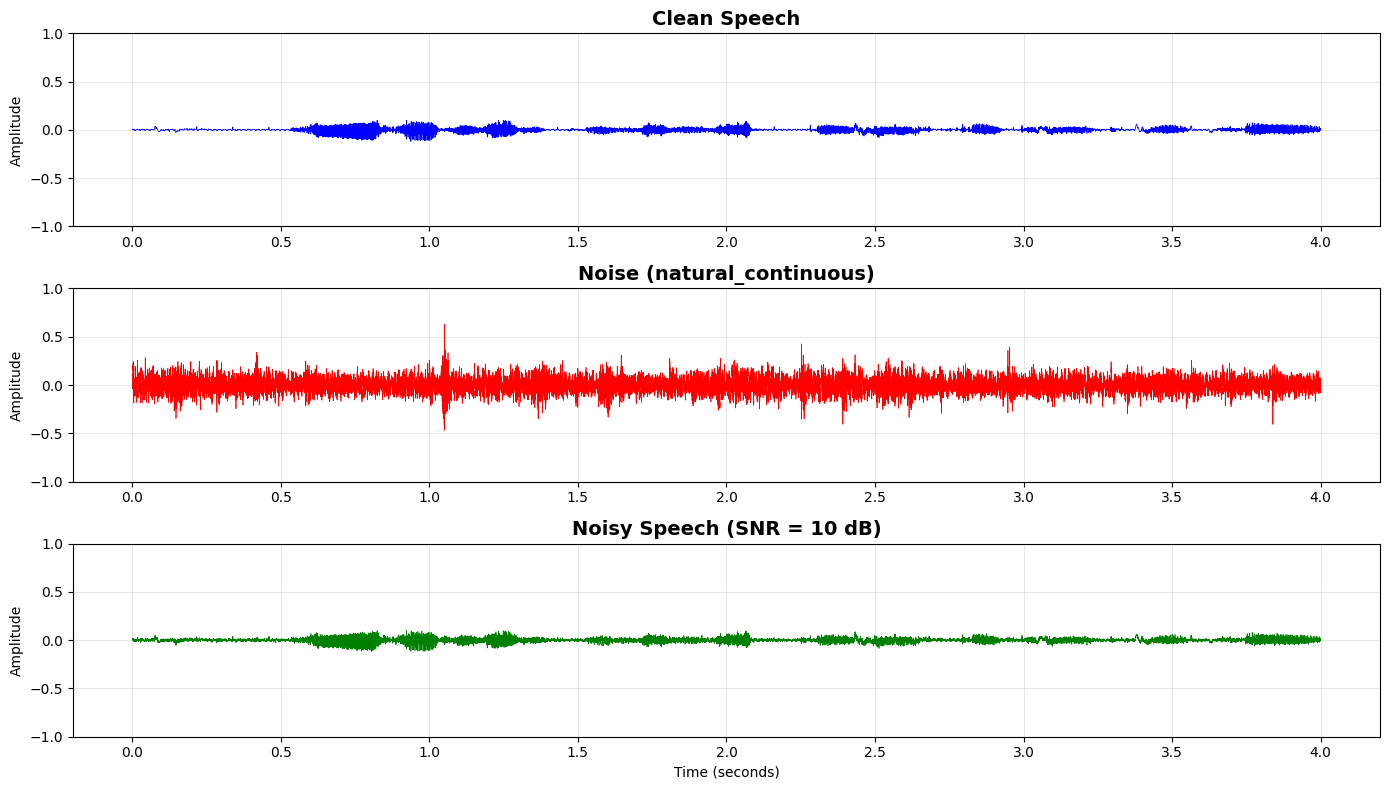

Waveform comparison complete


In [7]:
# Create time axis
time_axis = np.arange(len(clean_segment)) / SAMPLE_RATE

# Plot waveforms
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Clean speech
axes[0].plot(time_axis, clean_segment, linewidth=0.5, color='blue')
axes[0].set_title('Clean Speech', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1, 1)
axes[0].grid(True, alpha=0.3)

# Noise
axes[1].plot(time_axis, noise_segment, linewidth=0.5, color='red')
axes[1].set_title(f'Noise ({sample_noise_category})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim(-1, 1)
axes[1].grid(True, alpha=0.3)

# Noisy speech (clean + noise)
axes[2].plot(time_axis, noisy_segment, linewidth=0.5, color='green')
axes[2].set_title(f'Noisy Speech (SNR = {target_snr} dB)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Amplitude')
axes[2].set_ylim(-1, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Waveform comparison complete")

## 5. Visualization: Spectrograms

In [8]:
# Compute STFTs
clean_mag, clean_phase = compute_stft(clean_segment)
noise_mag, noise_phase = compute_stft(noise_segment)
noisy_mag, noisy_phase = compute_stft(noisy_segment)

print(f"Spectrogram shape: {clean_mag.shape}")
print(f"  Frequency bins: {clean_mag.shape[0]}")
print(f"  Time frames: {clean_mag.shape[1]}")

# Convert to dB scale for visualization
clean_db = librosa.amplitude_to_db(clean_mag, ref=np.max)
noise_db = librosa.amplitude_to_db(noise_mag, ref=np.max)
noisy_db = librosa.amplitude_to_db(noisy_mag, ref=np.max)

Spectrogram shape: (257, 501)
  Frequency bins: 257
  Time frames: 501


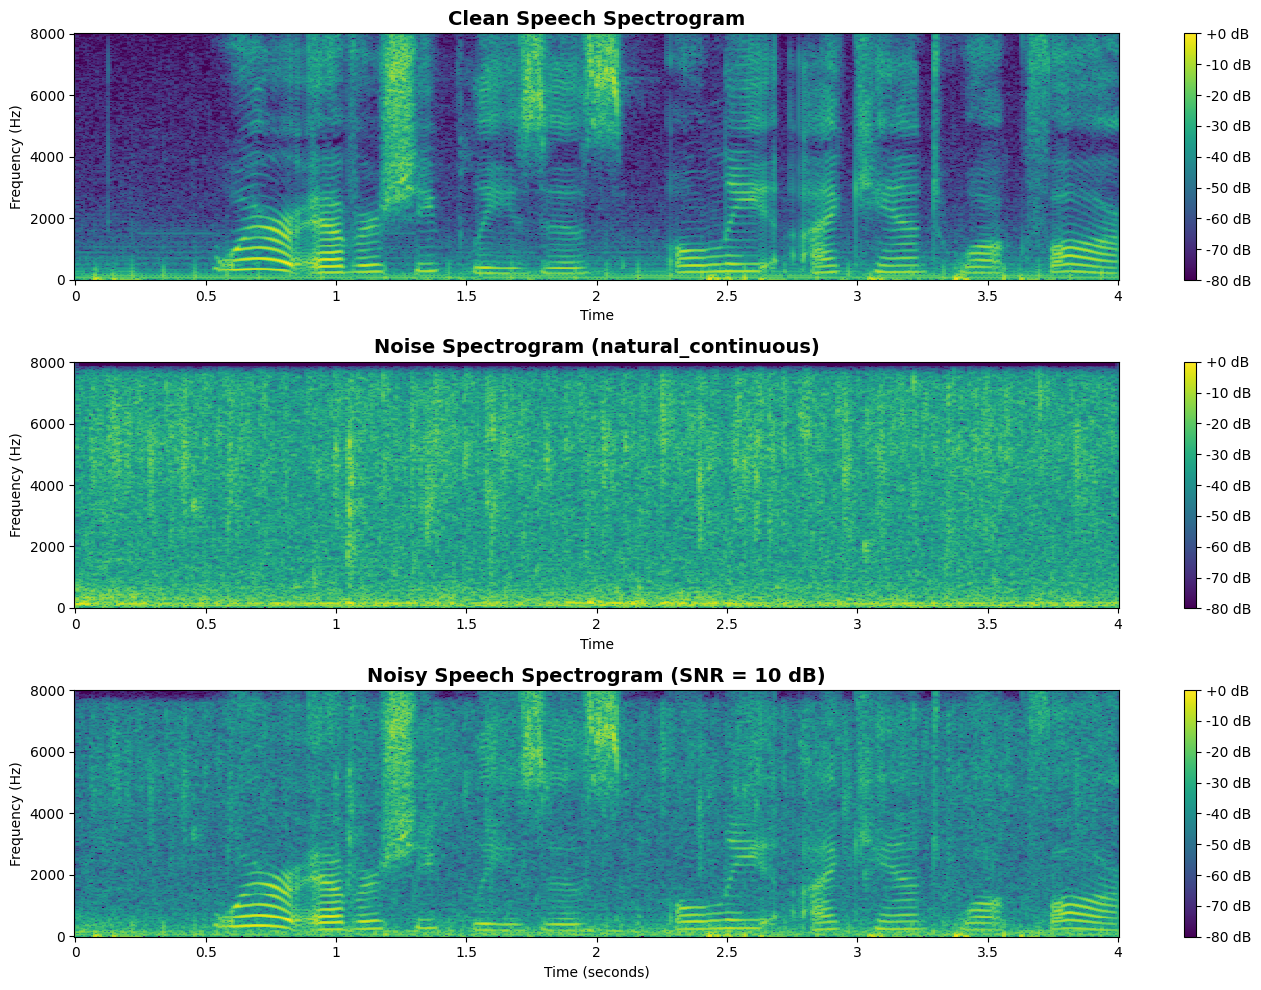

Spectrogram comparison complete


In [9]:
# Plot spectrograms
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Clean spectrogram
img1 = librosa.display.specshow(
    clean_db, 
    sr=SAMPLE_RATE, 
    hop_length=HOP_LENGTH,
    x_axis='time', 
    y_axis='hz',
    ax=axes[0],
    cmap='viridis'
)
axes[0].set_title('Clean Speech Spectrogram', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

# Noise spectrogram
img2 = librosa.display.specshow(
    noise_db, 
    sr=SAMPLE_RATE, 
    hop_length=HOP_LENGTH,
    x_axis='time', 
    y_axis='hz',
    ax=axes[1],
    cmap='viridis'
)
axes[1].set_title(f'Noise Spectrogram ({sample_noise_category})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency (Hz)')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

# Noisy spectrogram
img3 = librosa.display.specshow(
    noisy_db, 
    sr=SAMPLE_RATE, 
    hop_length=HOP_LENGTH,
    x_axis='time', 
    y_axis='hz',
    ax=axes[2],
    cmap='viridis'
)
axes[2].set_title(f'Noisy Speech Spectrogram (SNR = {target_snr} dB)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Frequency (Hz)')
fig.colorbar(img3, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("Spectrogram comparison complete")

## 6. Audio Playback (Optional)

Listen to the clean, noise, and noisy audio

In [10]:
print("Clean Speech:")
display(ipd.Audio(clean_segment, rate=SAMPLE_RATE))

print(f"\nNoise ({sample_noise_category}):")
display(ipd.Audio(noise_segment, rate=SAMPLE_RATE))

print(f"\nNoisy Speech (SNR = {target_snr} dB):")
display(ipd.Audio(noisy_segment, rate=SAMPLE_RATE))

Clean Speech:



Noise (natural_continuous):



Noisy Speech (SNR = 10 dB):


## 7. Compare Different SNR Levels

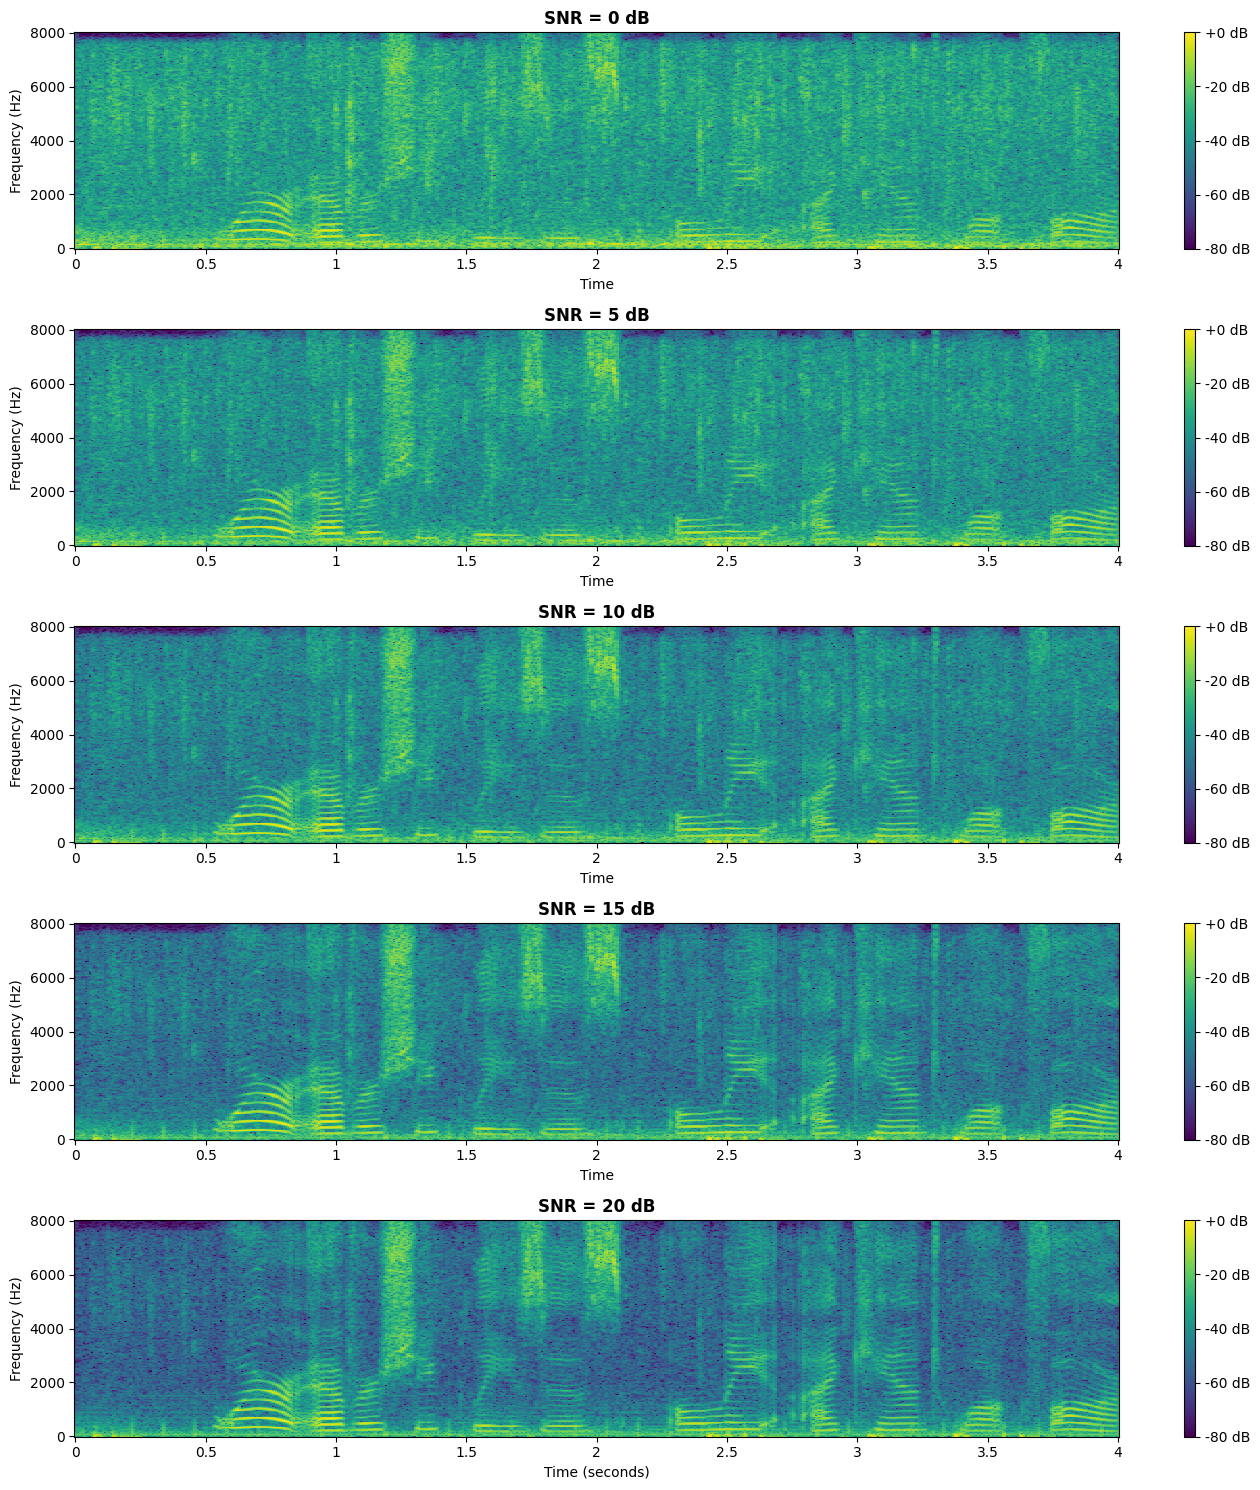

SNR comparison complete

Observation: Higher SNR = cleaner speech (speech dominates over noise)
Lower SNR = noisier speech (noise is more prominent)


In [11]:
# Visualize spectrograms at different SNR levels
fig, axes = plt.subplots(len(snr_levels), 1, figsize=(14, 3*len(snr_levels)))

for idx, snr in enumerate(snr_levels):
    noisy = noisy_versions[snr]
    noisy_mag, _ = compute_stft(noisy)
    noisy_db = librosa.amplitude_to_db(noisy_mag, ref=np.max)
    
    img = librosa.display.specshow(
        noisy_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='hz',
        ax=axes[idx],
        cmap='viridis'
    )
    axes[idx].set_title(f'SNR = {snr} dB', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

print("SNR comparison complete")
print("\nObservation: Higher SNR = cleaner speech (speech dominates over noise)")
print("Lower SNR = noisier speech (noise is more prominent)")

## 8. PyTorch Dataset Implementation

In [12]:
class SpeechEnhancementDataset(Dataset):
    """
    PyTorch Dataset for speech enhancement.
    Generates noisy/clean pairs on-the-fly during training.
    """
    
    def __init__(self, 
                 clean_files: list, 
                 noise_files: list,
                 snr_range: tuple = (0, 20),
                 segment_length: int = SEGMENT_SAMPLES,
                 sample_rate: int = SAMPLE_RATE):
        """
        Args:
            clean_files: List of paths to clean speech files
            noise_files: List of paths to noise files
            snr_range: (min_snr, max_snr) in dB
            segment_length: Length of audio segments in samples
            sample_rate: Audio sample rate
        """
        self.clean_files = clean_files
        self.noise_files = noise_files
        self.snr_range = snr_range
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        
        # Pre-load all clean audio and slice into segments
        print("Loading and slicing clean speech files...")
        self.clean_segments = []
        for clean_file in clean_files:
            audio = load_audio(str(clean_file), sr=sample_rate)
            segments = slice_audio(audio, segment_length)
            self.clean_segments.extend(segments)
        
        # Pre-load all noise audio and slice into segments
        print("Loading and slicing noise files...")
        self.noise_segments = []
        for noise_file in noise_files:
            audio = load_audio(str(noise_file), sr=sample_rate)
            segments = slice_audio(audio, segment_length)
            self.noise_segments.extend(segments)
        
        print(f"Dataset ready: {len(self.clean_segments)} clean segments, {len(self.noise_segments)} noise segments")
    
    def __len__(self):
        return len(self.clean_segments)
    
    def __getitem__(self, idx):
        # Get clean segment
        clean = self.clean_segments[idx]
        
        # Randomly select a noise segment
        noise = random.choice(self.noise_segments)
        
        # Random SNR
        snr = random.uniform(*self.snr_range)
        
        # Mix
        noisy = mix_at_snr(clean, noise, snr)
        
        # Compute spectrograms
        clean_mag, _ = compute_stft(clean)
        noisy_mag, noisy_phase = compute_stft(noisy)
        
        # Convert to tensors and add channel dimension
        noisy_tensor = torch.tensor(noisy_mag, dtype=torch.float32).unsqueeze(0)
        clean_tensor = torch.tensor(clean_mag, dtype=torch.float32).unsqueeze(0)
        
        return noisy_tensor, clean_tensor


print("✓ SpeechEnhancementDataset class defined")

✓ SpeechEnhancementDataset class defined


## 9. Create Dataset and DataLoader

In [13]:
# Create dataset with seen noise types (for training)
seen_noise_categories = ["natural_continuous", "domestic_mechanical"]
seen_noise_files = []

for category in seen_noise_categories:
    category_path = NOISE_DIR / category
    if category_path.exists():
        seen_noise_files.extend(list(category_path.glob("*.wav")))

print(f"Creating dataset with:")
print(f"  Clean files: {len(clean_files[:50])} (using first 50 for demo)")
print(f"  Noise files: {len(seen_noise_files)} from {seen_noise_categories}")

# Create dataset
dataset = SpeechEnhancementDataset(
    clean_files=clean_files[:50],  # Use subset for faster demo
    noise_files=seen_noise_files,
    snr_range=(SNR_MIN_DB, SNR_MAX_DB)
)

Creating dataset with:
  Clean files: 50 (using first 50 for demo)
  Noise files: 30 from ['natural_continuous', 'domestic_mechanical']
Loading and slicing clean speech files...
Loading and slicing noise files...
Dataset ready: 88 clean segments, 60 noise segments


In [14]:
# Create DataLoader
batch_size = 4
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0  # Set to 2-4 for faster loading in actual training
)

print(f"DataLoader created with batch size {batch_size}")
print(f"Total batches: {len(dataloader)}")

DataLoader created with batch size 4
Total batches: 22


## 10. Test the DataLoader

In [15]:
# Fetch one batch
noisy_batch, clean_batch = next(iter(dataloader))

print(f"Batch shapes:")
print(f"  Noisy: {noisy_batch.shape}  (batch, channels, freq_bins, time_frames)")
print(f"  Clean: {clean_batch.shape}")
print(f"\nData types:")
print(f"  Noisy: {noisy_batch.dtype}")
print(f"  Clean: {clean_batch.dtype}")
print(f"\nValue ranges:")
print(f"  Noisy: [{noisy_batch.min():.3f}, {noisy_batch.max():.3f}]")
print(f"  Clean: [{clean_batch.min():.3f}, {clean_batch.max():.3f}]")

Batch shapes:
  Noisy: torch.Size([4, 1, 257, 501])  (batch, channels, freq_bins, time_frames)
  Clean: torch.Size([4, 1, 257, 501])

Data types:
  Noisy: torch.float32
  Clean: torch.float32

Value ranges:
  Noisy: [0.000, 22.716]
  Clean: [0.000, 22.716]


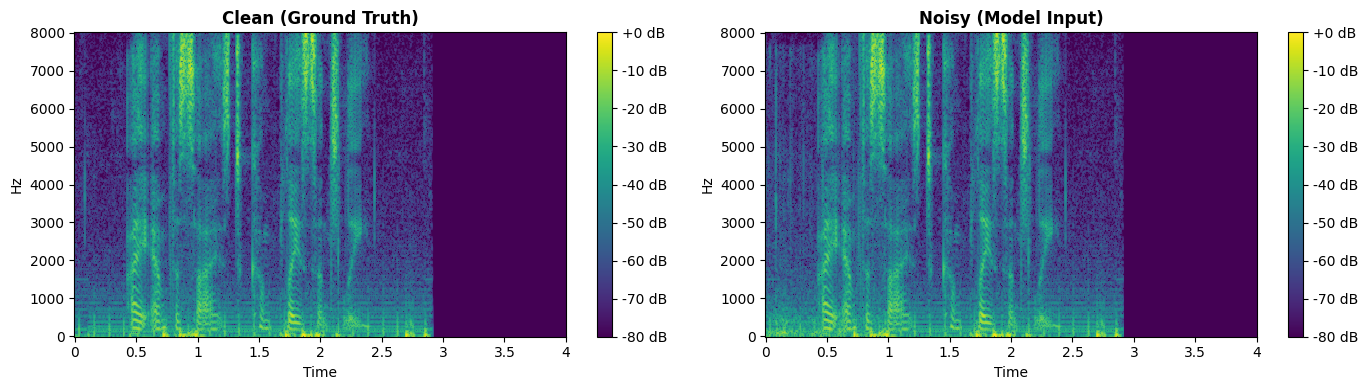


✓ DataLoader is working correctly!
This data is ready to be fed into a model for training.


In [16]:
# Visualize a sample from the batch
sample_idx = 0

noisy_spec = noisy_batch[sample_idx, 0].numpy()  # Remove batch and channel dims
clean_spec = clean_batch[sample_idx, 0].numpy()

# Convert to dB for visualization
noisy_db = librosa.amplitude_to_db(noisy_spec, ref=np.max)
clean_db = librosa.amplitude_to_db(clean_spec, ref=np.max)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

img1 = librosa.display.specshow(
    clean_db,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='hz',
    ax=axes[0],
    cmap='viridis'
)
axes[0].set_title('Clean (Ground Truth)', fontsize=12, fontweight='bold')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(
    noisy_db,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='hz',
    ax=axes[1],
    cmap='viridis'
)
axes[1].set_title('Noisy (Model Input)', fontsize=12, fontweight='bold')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("\n✓ DataLoader is working correctly!")
print("This data is ready to be fed into a model for training.")

## Summary

This notebook demonstrated:

1. ✅ **Loading audio files** — Clean speech from LibriSpeech and noise from ESC-50
2. ✅ **Mixing at controlled SNRs** — Synthetic generation of noisy/clean pairs
3. ✅ **Visualization** — Waveforms and spectrograms comparing clean, noise, and noisy audio
4. ✅ **PyTorch Dataset** — On-the-fly data generation with proper batching

**Next Steps:**
- Use this dataset with a CNN baseline model for training
- Experiment with different SNR ranges and noise types
- Implement the seen/unseen split for generalization experiments

**Key Takeaways:**
- Spectrograms computed on-the-fly → no storage needed for processed data
- Random SNR each epoch → infinite data augmentation
- Clear visual difference between clean and noisy → model has learnable signal